Project Overview

In [ ]:
# This project analyzes UPI transactions to understand:

# - Spending patterns
# - Customer behavior
# - Fraud risk
# - Transaction reliability

# Tools Used:
# - SQL
# - Python (Pandas)
# - Power B

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('upi_transactions_2024.csv')
print(df)

       transaction id            timestamp transaction type merchant_category  \
0       TXN0000000001  2024-10-08 15:17:28              P2P     Entertainment   
1       TXN0000000002  2024-04-11 06:56:00              P2M           Grocery   
2       TXN0000000003  2024-04-02 13:27:18              P2P           Grocery   
3       TXN0000000004  2024-01-07 10:09:17              P2P              Fuel   
4       TXN0000000005  2024-01-23 19:04:23              P2P          Shopping   
...               ...                  ...              ...               ...   
249995  TXN0000249996  2024-11-08 22:41:43         Recharge              Food   
249996  TXN0000249997  2024-12-15 02:58:03              P2P         Utilities   
249997  TXN0000249998  2024-11-27 16:33:25              P2P              Food   
249998  TXN0000249999  2024-01-05 13:31:30         Recharge        Healthcare   
249999  TXN0000250000  2024-01-17 15:23:07              P2P     Entertainment   

        amount (INR) transa

Data Understanding

In [ ]:
# Key Columns:

# - amount_inr
# - merchant_category
# - sender_age_group
# - sender_state
# - sender_bank
# - device_type
# - network_type
# - fraud_flag
# - transaction_status

In [ ]:
df.head()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   transaction id      250000 non-null  object
 1   timestamp           250000 non-null  object
 2   transaction type    250000 non-null  object
 3   merchant_category   250000 non-null  object
 4   amount (INR)        250000 non-null  int64 
 5   transaction_status  250000 non-null  object
 6   sender_age_group    250000 non-null  object
 7   receiver_age_group  250000 non-null  object
 8   sender_state        250000 non-null  object
 9   sender_bank         250000 non-null  object
 10  receiver_bank       250000 non-null  object
 11  device_type         250000 non-null  object
 12  network_type        250000 non-null  object
 13  fraud_flag          250000 non-null  int64 
 14  hour_of_day         250000 non-null  int64 
 15  day_of_week         250000 non-null  object
 16  is

In [ ]:
df.shape

(250000, 17)

In [ ]:
df.columns

Index(['transaction id', 'timestamp', 'transaction type', 'merchant_category',
       'amount (INR)', 'transaction_status', 'sender_age_group',
       'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank',
       'device_type', 'network_type', 'fraud_flag', 'hour_of_day',
       'day_of_week', 'is_weekend'],
      dtype='object')

In [ ]:
df.describe()

,amount (INR),fraud_flag,hour_of_day,is_weekend
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,1311.756036,0.001920,14.681032,0.285348
std,1848.059224,0.043776,5.188304,0.451581
min,10.000000,0.000000,0.000000,0.000000
25%,288.000000,0.000000,11.000000,0.000000
50%,629.000000,0.000000,15.000000,0.000000
75%,1596.000000,0.000000,19.000000,1.000000
max,42099.000000,1.000000,23.000000,1.000000


In [ ]:
df.isnull().sum()

,0
transaction id,0
timestamp,0
transaction type,0
merchant_category,0
amount (INR),0
transaction_status,0
sender_age_group,0
receiver_age_group,0
sender_state,0
sender_bank,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['timestamp']=pd.to_datetime(df['timestamp'])     # changing the 'timestamp' dtype from object to 'datetime'.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   transaction id      250000 non-null  object        
 1   timestamp           250000 non-null  datetime64[ns]
 2   transaction type    250000 non-null  object        
 3   merchant_category   250000 non-null  object        
 4   amount (INR)        250000 non-null  int64         
 5   transaction_status  250000 non-null  object        
 6   sender_age_group    250000 non-null  object        
 7   receiver_age_group  250000 non-null  object        
 8   sender_state        250000 non-null  object        
 9   sender_bank         250000 non-null  object        
 10  receiver_bank       250000 non-null  object        
 11  device_type         250000 non-null  object        
 12  network_type        250000 non-null  object        
 13  fraud_flag          250000 no

In [ ]:
df['month']=df['timestamp'].dt.month_name()    # creating separate month column

In [ ]:
df[['timestamp','month']].head()

,timestamp,month
0,2024-10-08 15:17:28,October
1,2024-04-11 06:56:00,April
2,2024-04-02 13:27:18,April
3,2024-01-07 10:09:17,January
4,2024-01-23 19:04:23,January


In [ ]:
df['hour']=df['timestamp'].dt.hour     # separate hour column

In [ ]:
df[['timestamp','hour']].head()

,timestamp,hour
0,2024-10-08 15:17:28,15
1,2024-04-11 06:56:00,6
2,2024-04-02 13:27:18,13
3,2024-01-07 10:09:17,10
4,2024-01-23 19:04:23,19


In [ ]:
df['day_name']=df['timestamp'].dt.day_name()     # separate day name

In [ ]:
df[['timestamp','day_name']].head()

,timestamp,day_name
0,2024-10-08 15:17:28,Tuesday
1,2024-04-11 06:56:00,Thursday
2,2024-04-02 13:27:18,Tuesday
3,2024-01-07 10:09:17,Sunday
4,2024-01-23 19:04:23,Tuesday


# Fraud Analysis

Identifying fraud-prone regions, devices, and customer segments.

In [ ]:
df['transaction_status'].value_counts()

,count
transaction_status,
SUCCESS,237624
FAILED,12376


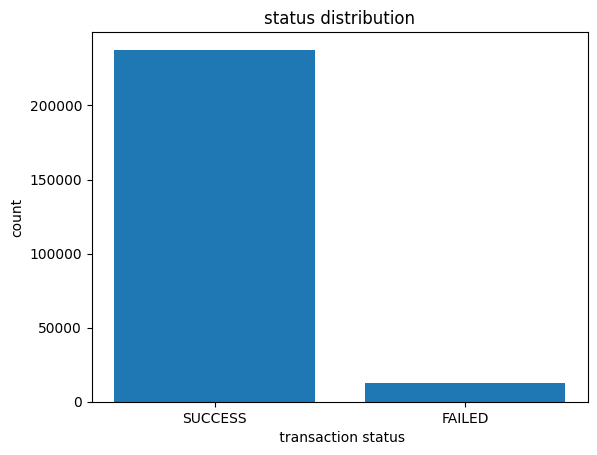

In [ ]:
status_count=df['transaction_status'].value_counts()

plt.bar(x=status_count.index,height=status_count.values)
plt.title('status distribution')
plt.xlabel(' transaction status')
plt.ylabel('count')
plt.show()

In [ ]:
fail_rate=(df['transaction_status'].value_counts(normalize=True)*100)
fail_rate

,proportion
transaction_status,
SUCCESS,95.0496
FAILED,4.9504


In [ ]:
failed_transaction=df[df['transaction_status']=='FAILED']

In [ ]:
failed_transaction['network_type'].value_counts()

,count
network_type,
4G,7464
5G,3039
WiFi,1222
3G,651


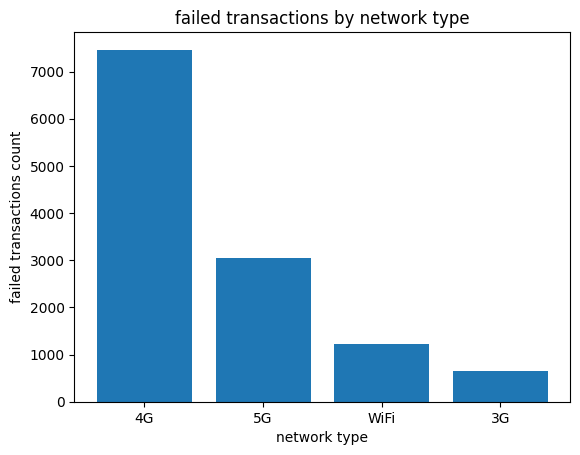

In [ ]:
transaction=failed_transaction['network_type'].value_counts()
plt.bar(x=transaction.index,height=transaction.values)
plt.title('failed transactions by network type')
plt.xlabel('network type')
plt.ylabel('failed transactions count')
plt.show()

In [ ]:
fail_transactions_rate=failed_transaction['network_type'].value_counts(normalize=True)*100
fail_transactions_rate

,proportion
network_type,
4G,60.310278
5G,24.555591
WiFi,9.873950
3G,5.260181


In [ ]:
df['fraud_flag'].value_counts()

,count
fraud_flag,
0,249520
1,480


In [ ]:
fraud_rate_by_type=(
    df.groupby('transaction type')['fraud_flag']
    .mean()*100).sort_values(ascending=False)

fraud_rate_by_type

,fraud_flag
transaction type,
Recharge,0.239483
Bill Payment,0.206059
P2M,0.190509
P2P,0.183201


In [ ]:
fraud_rate_by_category=(
    df.groupby('merchant_category')['fraud_flag']
    .mean()*100).sort_values(ascending=False)

fraud_rate_by_category

,fraud_flag
merchant_category,
Transport,0.213877
Education,0.210582
Shopping,0.207552
Other,0.201386
Entertainment,0.198975
Food,0.194854
Fuel,0.191517
Grocery,0.188128
Healthcare,0.165837


In [ ]:
fraud_by_age=(
    df.groupby('sender_age_group')['fraud_flag']
    .mean()*100).sort_values(ascending=False)

fraud_by_age

,fraud_flag
sender_age_group,
18-25,0.229369
56+,0.215845
26-35,0.186431
36-45,0.184499
46-55,0.124794


In [115]:
fraud_by_state=(
    df.groupby('sender_state')['fraud_flag']
    .mean()*100).sort_values(ascending=True)

fraud_by_state

,fraud_flag
sender_state,
Tamil Nadu,0.157685
Uttar Pradesh,0.172614
Telangana,0.173836
Andhra Pradesh,0.174948
West Bengal,0.175245
Maharashtra,0.189703
Delhi,0.201045
Gujarat,0.214346
Rajasthan,0.230219


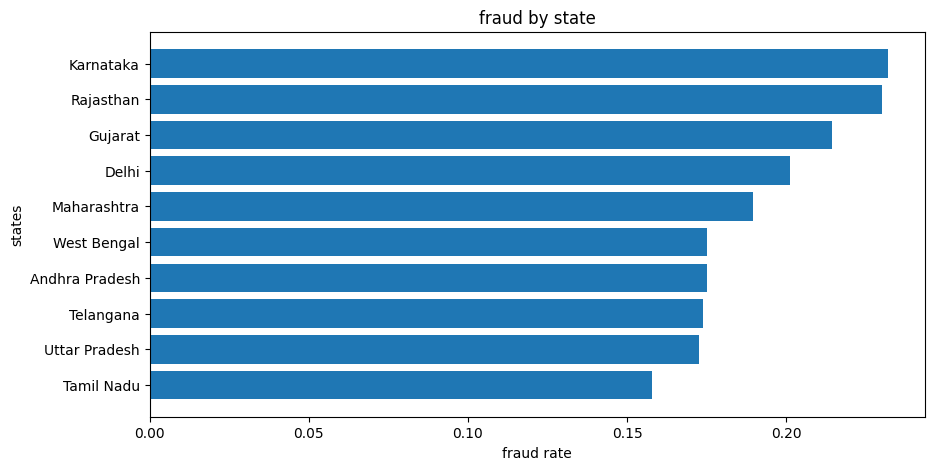

In [116]:
plt.figure(figsize=(10,5))
plt.barh(y=fraud_by_state.index,width=fraud_by_state)
plt.title('fraud by state')
plt.xlabel('fraud rate')
plt.ylabel('states')
plt.show()

In [ ]:
fraud_by_hour=(
    df.groupby('hour')['fraud_flag']
    .mean()*100).sort_values(ascending=False)

fraud_by_hour.head(10)

,fraud_flag
hour,
3,0.304414
1,0.267380
15,0.253485
22,0.245622
0,0.236128
7,0.230906
16,0.221555
8,0.215595
21,0.215345


In [ ]:
df.groupby('fraud_flag')['amount (INR)'].mean()

,amount (INR)
fraud_flag,
0,1311.395391
1,1499.231250


In [ ]:
df.groupby('fraud_flag')['amount (INR)'].describe()

,count,mean,std,min,25%,50%,75%,max
fraud_flag,,,,,,,,
0,249520.0,1311.395391,1847.210565,10.0,288.0,629.0,1596.0,42099.0
1,480.0,1499.231250,2240.707939,28.0,260.0,618.5,1673.5,17718.0


In [ ]:
df.groupby('sender_age_group')['amount (INR)'].mean().sort_values(ascending=False)

,amount (INR)
sender_age_group,
36-45,1424.041242
46-55,1333.129141
26-35,1326.285239
18-25,1194.545449
56+,1187.568631


In [ ]:
df.groupby('hour').size().sort_values(ascending=False)

,0
hour,
19,21232
18,20064
20,18506
17,18340
12,17516
11,16328
21,16253
13,15038
16,13992


# Spending Analysis

Analyzing transaction value across categories, states, banks, and age groups.

In [ ]:
merchant=df.groupby('merchant_category')['amount (INR)'].sum().sort_values(ascending=False)
merchant

,amount (INR)
merchant_category,
Shopping,76863207
Grocery,58277893
Utilities,52742482
Fuel,38982575
Education,38704346
Other,21073449
Food,19919402
Entertainment,8309080
Healthcare,6874159


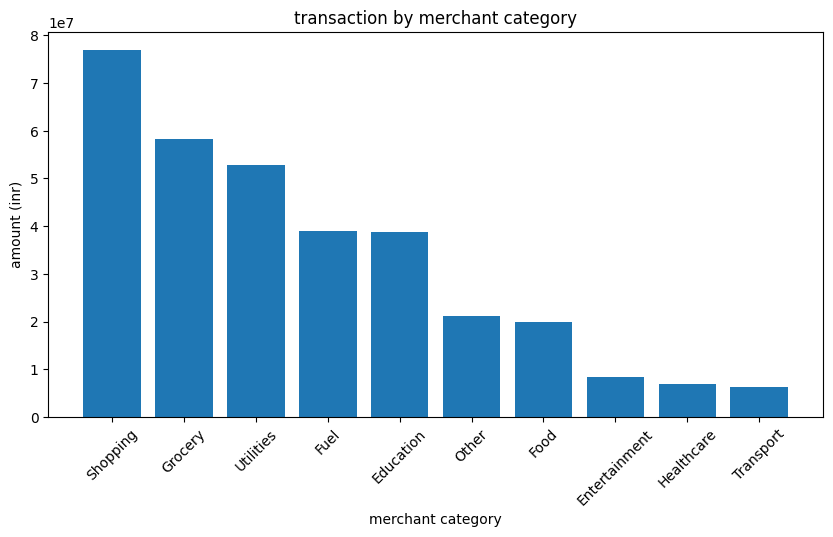

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(x=merchant.index,height=merchant.values)
plt.title('transaction by merchant category')
plt.xlabel('merchant category')
plt.ylabel('amount (inr)')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df['merchant_category'].value_counts()

,count
merchant_category,
Grocery,49966
Food,37464
Shopping,29872
Fuel,25063
Other,24828
Utilities,22338
Transport,20105
Entertainment,20103
Healthcare,12663


In [ ]:
df.groupby('merchant_category')['amount (INR)'].mean().sort_values(ascending=False)

,amount (INR)
merchant_category,
Education,5094.017636
Shopping,2573.085398
Utilities,2361.110305
Fuel,1555.383434
Grocery,1166.350979
Other,848.777550
Healthcare,542.853905
Food,531.694480
Entertainment,413.325374


In [ ]:
df.groupby('hour')['amount (INR)'].sum().sort_values(ascending=False).head(10)

,amount (INR)
hour,
19,28223522
18,26297174
17,24514186
20,23822014
12,23406280
11,21193161
21,20995491
13,19847819
10,18337313


In [ ]:
df.groupby('is_weekend')['amount (INR)'].agg(['count','mean','sum'])

,count,mean,sum
is_weekend,,,
0,178663,1312.518703,234498529
1,71337,1309.845942,93440480


In [ ]:
df.groupby('day_of_week')['amount (INR)'].agg(['count','mean','sum'])

,count,mean,sum
day_of_week,,,
Friday,35496,1305.290258,46332583
Monday,36495,1312.040225,47882908
Saturday,35334,1298.124639,45867936
Sunday,36003,1321.349443,47572544
Thursday,35432,1315.787565,46620985
Tuesday,35540,1318.131401,46846390
Wednesday,35700,1311.363109,46815663


In [ ]:
df.groupby('sender_age_group')['amount (INR)'].agg(['count','mean','sum'])

,count,mean,sum
sender_age_group,,,
18-25,62345,1194.545449,74473936
26-35,87432,1326.285239,115959771
36-45,62873,1424.041242,89533745
46-55,24841,1333.129141,33116261
56+,12509,1187.568631,14855296


In [ ]:
df.groupby('sender_state')['amount (INR)'].agg(['count','mean','sum']).sort_values('sum',ascending=False)

,count,mean,sum
sender_state,,,
Maharashtra,37427,1310.389505,49043948
Uttar Pradesh,30125,1328.986456,40035717
Karnataka,29756,1292.215284,38451158
Tamil Nadu,25367,1314.444672,33343518
Delhi,24870,1314.429634,32689865
Telangana,22435,1326.094495,29750930
Rajasthan,19981,1337.794405,26730470
Gujarat,20061,1295.458352,25988190
Andhra Pradesh,20006,1297.241777,25952619


In [ ]:
df.groupby('device_type')['amount (INR)'].agg(['count','mean','sum'])

,count,mean,sum
device_type,,,
Android,187777,1313.984599,246736086
Web,12610,1300.810071,16403215
iOS,49613,1306.103400,64799708


# Customer Behavior Analysis

Understanding how spending habits differ across customer segments.

In [ ]:
hourly_spend=df.groupby('hour')['amount (INR)'].sum().reset_index().sort_values('hour')
hourly_spend.head(10)

,hour,amount (INR)
0,0,4532884
1,1,2914350
2,2,2173750
3,3,1678669
4,4,1670700
5,5,2134122
6,6,4617034
7,7,7482766
8,8,10979614
9,9,13809021


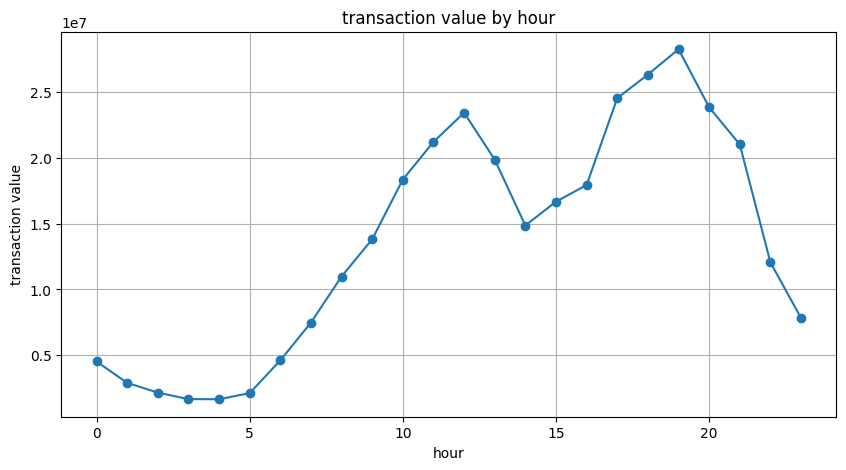

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(hourly_spend['hour'],hourly_spend['amount (INR)'],marker='o')
plt.title('transaction value by hour')
plt.xlabel('hour')
plt.ylabel('transaction value')
plt.grid(True)
plt.show()

In [ ]:
avg_transaction=df.groupby('sender_age_group')['amount (INR)'].mean().reset_index()
avg_transaction

,sender_age_group,amount (INR)
0,18-25,1194.545449
1,26-35,1326.285239
2,36-45,1424.041242
3,46-55,1333.129141
4,56+,1187.568631


In [ ]:
age_category=df.groupby(['sender_age_group','merchant_category'])['amount (INR)'].sum().reset_index()

age_category['share']=(age_category['amount (INR)']/age_category.groupby('sender_age_group')['amount (INR)'].transform('sum'))*100
age_category.head(10)

,sender_age_group,merchant_category,amount (INR),share
0,18-25,Education,5975262,8.023293
1,18-25,Entertainment,2472467,3.319909
2,18-25,Food,5349000,7.182379
3,18-25,Fuel,8670515,11.642348
4,18-25,Grocery,11834486,15.890776
5,18-25,Healthcare,1057729,1.420267
6,18-25,Other,5691302,7.642005
7,18-25,Shopping,22877040,30.718183
8,18-25,Transport,1734166,2.328554
9,18-25,Utilities,8811969,11.832286


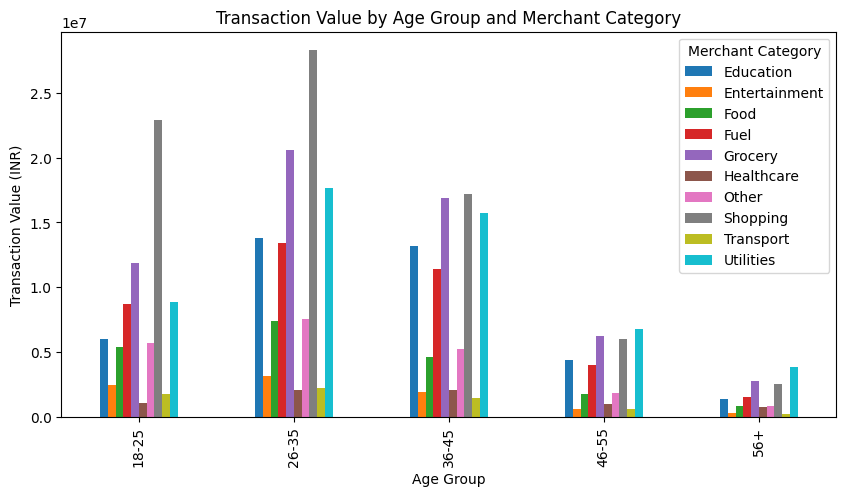

In [126]:
age_merchant = (
    df.groupby(['sender_age_group','merchant_category'])['amount (INR)']
      .sum()
      .unstack())

age_merchant.plot(kind='bar',figsize=(10,5))
plt.title('Transaction Value by Age Group and Merchant Category')
plt.xlabel('Age Group')
plt.ylabel('Transaction Value (INR)')
plt.legend(title='Merchant Category')
plt.show()

# Reliability Analysis

Analyzing transaction failures across banks, devices, and networks.

In [ ]:
network_failure=df.groupby('network_type').agg(failure_rate=('transaction_status',lambda x:(x=='FAILED').mean()*100)).reset_index()
network_failure

,network_type,failure_rate
0,3G,5.220111
1,4G,4.982211
2,5G,4.856029
3,WiFi,4.861940


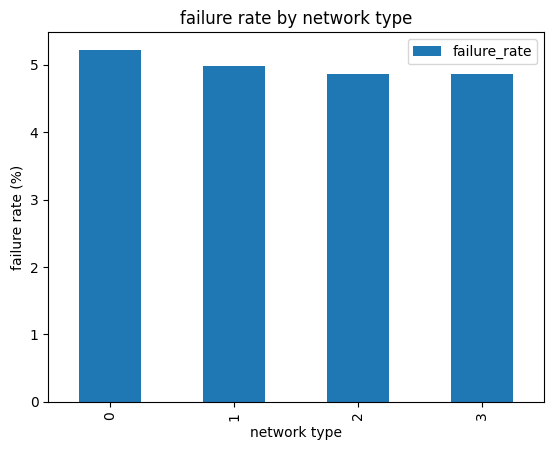

In [ ]:
network_failure.plot(kind='bar')
plt.title('failure rate by network type')
plt.xlabel('network type')
plt.ylabel('failure rate (%)')
plt.show()

In [ ]:
bank_failure=df.groupby('sender_bank').agg(failure_rate=('transaction_status',lambda x:(x=='FAILED').mean()*100)).reset_index()
bank_failure

,sender_bank,failure_rate
0,Axis,4.947688
1,HDFC,4.823263
2,ICICI,5.035440
3,IndusInd,4.953720
4,Kotak,4.982029
5,PNB,4.894572
6,SBI,4.936755
7,Yes Bank,5.104586


In [ ]:
device_failure=df.groupby('device_type').agg(failure_rate=('transaction_status',lambda x:(x=='FAILED').mean()*100)).reset_index()
device_failure

,device_type,failure_rate
0,Android,4.940967
1,Web,5.154639
2,iOS,4.934191


In [ ]:
transaction_failure_rate=(
    df.groupby('transaction type')['transaction_status']
    .apply(lambda x:(x=='FAILED').mean()*100)
    .sort_values(ascending=False)
)

transaction_failure_rate

,transaction_status
transaction type,
Recharge,5.092999
P2P,4.957979
P2M,4.949806
Bill Payment,4.881182


In [ ]:
age_category=pd.pivot_table(
    df,
    values='amount (INR)',
    index='sender_age_group',
    columns='merchant_category',
    aggfunc='sum'
)

age_category

merchant_category,Education,Entertainment,Food,Fuel,Grocery,Healthcare,Other,Shopping,Transport,Utilities
sender_age_group,,,,,,,,,,
18-25,5975262,2472467,5349000,8670515,11834486,1057729,5691302,22877040,1734166,8811969
26-35,13757322,3107354,7365531,13376810,20589919,2056767,7554490,28310939,2191894,17648745
36-45,13198094,1866565,4628046,11395137,16853952,2015922,5188137,17217294,1473606,15696992
46-55,4389855,605017,1756995,4003156,6233102,966820,1840867,5978073,584008,6758368
56+,1383813,257677,819830,1536957,2766434,776921,798653,2479861,208742,3826408


In [ ]:
pd.pivot_table(
    df,
    values='amount (INR)',
    index='sender_age_group',
    columns='merchant_category',
    aggfunc='mean'
)

merchant_category,Education,Entertainment,Food,Fuel,Grocery,Healthcare,Other,Shopping,Transport,Utilities
sender_age_group,,,,,,,,,,
18-25,3097.595645,502.329744,570.195075,1387.726472,951.784301,332.723813,920.624717,3034.895198,340.700589,1619.251929
26-35,5287.210607,440.259847,560.031250,1531.052993,1177.441471,471.735550,870.734209,2741.448533,308.630527,2225.286219
36-45,6716.587277,365.706309,497.158234,1777.435190,1341.554724,623.931291,817.673286,2312.287671,303.398394,2782.168026
46-55,5900.342742,301.153310,469.533672,1674.260142,1253.892979,778.438003,756.935444,1948.524446,283.086767,3101.591556
56+,3865.399441,255.125743,436.079787,1204.511755,1101.726006,1193.427035,669.449288,1660.991962,210.213494,3344.762238


In [ ]:
hour_category=pd.pivot_table(
    df,
    values='amount (INR)',
    index='hour',
    columns='merchant_category',
    aggfunc='sum'
)

hour_category.idxmax()

,0
merchant_category,
Education,19
Entertainment,19
Food,19
Fuel,19
Grocery,19
Healthcare,19
Other,19
Shopping,19
Transport,18


In [ ]:
pd.crosstab(
    df['sender_age_group'],
    df['transaction type'],
    normalize='index'
)*100

transaction type,Bill Payment,P2M,P2P,Recharge
sender_age_group,,,,
18-25,14.902558,34.968321,45.102254,5.026867
26-35,14.977354,35.225089,44.771937,5.025620
36-45,15.011213,35.056384,44.950933,4.981471
46-55,14.757860,35.155590,45.183366,4.903184
56+,15.013191,34.271325,45.527220,5.188264


In [ ]:
df.to_csv('upi_cleaned.csv',index=False)

In [ ]:
import os
os.listdir()

['.config', 'upi_transactions_2024.csv', 'upi_cleaned.csv', 'sample_data']

In [ ]:
df.columns = [
    'transaction_id',
    'timestamp',
    'transaction_type',
    'merchant_category',
    'amount_inr',
    'transaction_status',
    'sender_age_group',
    'receiver_age_group',
    'sender_state',
    'sender_bank',
    'receiver_bank',
    'device_type',
    'network_type',
    'fraud_flag',
    'hour_of_day',
    'day_of_week',
    'is_weekend',
    'month',
    'hour',
    'day_name'
]

In [ ]:
df.columns

In [ ]:
from google.colab import files
files.download('upi_cleaned.csv')

key Insights

In [ ]:
## Spending Analysis

# - Shopping was the highest-value merchant category, contributing ₹76.9M in transaction value.
# - Maharashtra generated the highest transaction value among all states.
# - SBI held the largest market share, contributing approximately 25% of total transaction value.

## Customer Behavior Analysis

# - Users aged 26–35 contributed approximately 35% of total transaction value.
# - Spending behavior shifted from Shopping towards Utilities as age increased.
# - Peak transaction activity occurred around 7 PM.
# - Weekend spending represented roughly 28–29% of total spending across all age groups.

## Risk Analysis

# - Karnataka and Rajasthan exhibited the highest fraud rates.
# - Maharashtra had the highest fraud exposure due to its large transaction volume.
# - 3G networks showed the highest transaction failure rates.
# - Web-based transactions had the highest fraud rate among device types.